# mjo_cross

- "Calculate space-time cross spectrum over multiple segments"
- [NCL Reference](https://www.ncl.ucar.edu/Document/Functions/Diagnostics/mjo_cross.shtml)

### Input Data
- X: (time, lat, lon)
- Y: (time, lat, lon)
- segLength: length of segment
- segOverlap: overlap of the segment

### Returns:
Three-dimensional array (16, wavenumber, frequency)

The return variable will be a three-dimensional array (16,wavenumber,frequency) containing the 16 cross spectral quantities averaged over all segments.

         ( 0,:,:)  -  symmetric power spectrum of x
         ( 1,:,:)  -  asymmetric power spectrum of x
         ( 2,:,:)  -  symmetric power spectrum of y
         ( 3,:,:)  -  asymmetric power spectrum of y
         ( 4,:,:)  -  symmetric cospectrum
         ( 5,:,:)  -  asymmetric cospectrum
         ( 6,:,:)  -  symmetric quadrature spectrum
         ( 7,:,:)  -  asymmetric quadrature spectrum
         ( 8,:,:)  -  symmetric coherence-squared spectrum
         ( 9,:,:)  -  asymmetric coherence-squared spectrum
         (10,:,:)  -  symmetric phase spectrum
         (11,:,:)  -  asymmetric phase spectrum
         (12,:,:)  -  symmetric component-1 phase spectrum
         (13,:,:)  -  asymmetric component-1 phase spectrum
         (14,:,:)  -  symmetric component-2 phase spectrum
         (15,:,:)  -  asymmetric component-2 phase spectrum


In [1]:
import os
import xarray as xr
import numpy as np
from scipy import signal # csd: cross-spectral density/power
import xrft # xarray FFT

In [4]:
latS = -15
latN = 15

time_start = "1979-01-01"
time_end = "1981-12-31"

In [5]:
u850_data = xr.open_dataset(os.getcwd() + "/data/anomaly/QBOi.EXP1.AMIP.001.u850.day.anom.nc")
u850_data = u850_data.sel(time=slice(time_start, time_end), lat=slice(latS, latN))
u850_data

<xarray.Dataset> Size: 40MB
Dimensions:  (time: 1095, lat: 32, lon: 288)
Coordinates:
  * time     (time) object 9kB 1979-01-01 00:00:00 ... 1981-12-31 00:00:00
  * lat      (lat) float64 256B -14.61 -13.66 -12.72 ... 12.72 13.66 14.61
  * lon      (lon) float64 2kB 0.0 1.25 2.5 3.75 5.0 ... 355.0 356.3 357.5 358.8
Data variables:
    date     (time) float64 9kB ...
    U850     (time, lat, lon) float32 40MB ...

In [6]:
flut_data = xr.open_dataset(os.getcwd() + "/data/anomaly/QBOi.EXP1.AMIP.001.flut.day.anom.nc")
flut_data = flut_data.sel(time=slice(time_start, time_end), lat=slice(latS, latN))
flut_data

<xarray.Dataset> Size: 40MB
Dimensions:  (time: 1095, lat: 32, lon: 288)
Coordinates:
  * time     (time) object 9kB 1979-01-01 00:00:00 ... 1981-12-31 00:00:00
  * lat      (lat) float64 256B -14.61 -13.66 -12.72 ... 12.72 13.66 14.61
  * lon      (lon) float64 2kB 0.0 1.25 2.5 3.75 5.0 ... 355.0 356.3 357.5 358.8
Data variables:
    date     (time) float64 9kB ...
    FLUT     (time, lat, lon) float32 40MB ...
Attributes:
    history:  Thu Mar  6 13:31:31 2025: ncatted -a cell_methods,FLUT,m,c,time...
    NCO:      netCDF Operators version 5.3.1 (Homepage = http://nco.sf.net, C...

#### Symmetric Power Spectrum of x and y

In [7]:
# Compute the power spectrum along the time dimension

# X:
u850_xr = u850_data.to_dataarray(name="u850")
u850_xr = u850_xr.chunk({'time': -1, 'lat': 100, 'lon': 100, 'variable': 100}) # chunking large dataset to run xrft
fft_x = xrft.fft(u850_xr, dim=['time'])
power_spectrum = np.abs(fft_x)**2
power_spectrum

<xarray.DataArray (variable: 2, freq_time: 1095, lat: 32, lon: 288)> Size: 161MB
dask.array<pow, shape=(2, 1095, 32, 288), dtype=float64, chunksize=(2, 1095, 32, 100), chunktype=numpy.ndarray>
Coordinates:
  * variable   (variable) object 16B 'date' 'U850'
  * freq_time  (freq_time) float64 9kB -5.782e-06 -5.771e-06 ... 5.782e-06
  * lat        (lat) float64 256B -14.61 -13.66 -12.72 ... 12.72 13.66 14.61
  * lon        (lon) float64 2kB 0.0 1.25 2.5 3.75 ... 355.0 356.3 357.5 358.8

In [8]:
# Compute the power spectrum along the time dimension

# Y:
flut_xr = flut_data.to_dataarray(name="flut")
flut_xr = flut_xr.chunk({'time': -1, 'lat': 100, 'lon': 100, 'variable': 100}) # chunking large dataset to run xrft
fft_x = xrft.fft(flut_xr, dim=['time'])
power_spectrum = np.abs(fft_x)**2
power_spectrum

<xarray.DataArray (variable: 2, freq_time: 1095, lat: 32, lon: 288)> Size: 161MB
dask.array<pow, shape=(2, 1095, 32, 288), dtype=float64, chunksize=(2, 1095, 32, 100), chunktype=numpy.ndarray>
Coordinates:
  * variable   (variable) object 16B 'date' 'FLUT'
  * freq_time  (freq_time) float64 9kB -5.782e-06 -5.771e-06 ... 5.782e-06
  * lat        (lat) float64 256B -14.61 -13.66 -12.72 ... 12.72 13.66 14.61
  * lon        (lon) float64 2kB 0.0 1.25 2.5 3.75 ... 355.0 356.3 357.5 358.8

## Previous:

In [4]:
segLen = 256        # 256 time steps (256 days in daily data)
segOverLap = 50     # 15 time steps of overlap

freqs, cps = signal.csd(u850_data["U850"], flut_data["FLUT"],
                        nperseg=segLen, noverlap=segOverLap,
                       scaling="spectrum") # cross power spectrum

In [5]:
cps_mag = np.abs(cps)
cps_phase = np.angle(cps, deg=True)

In [6]:
print(u850_data["U850"].shape)
print(flut_data["FLUT"].shape)
print(f"time = {cps_mag.shape[0]}, lat = {cps_mag.shape[1]}, lon = {cps_mag.shape[2]}")

(2555, 192, 288)
(2555, 192, 288)
time = 2555, lat = 192, lon = 129


In [7]:
print(cps_mag.shape)
print(cps_phase.shape)
print(freqs.shape)

(2555, 192, 129)
(2555, 192, 129)
(129,)


ValueError: x and y must have same first dimension, but have shapes (129,) and (2555, 192, 129)

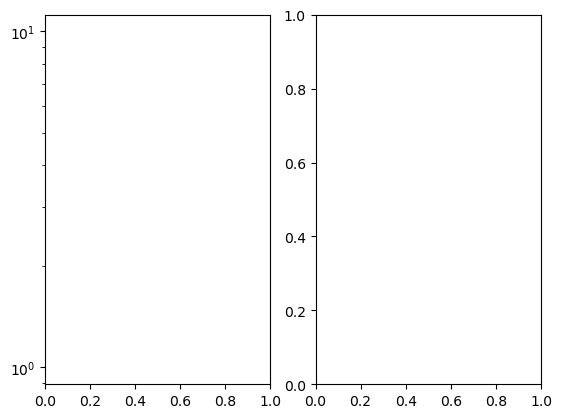

In [8]:
import matplotlib.pyplot as plt

max_wave_plot = 15 # min/max wavenumber to plot on the x-axis (default = 15)
tx_string = "Cross-Spectrum over Multiple Segments" # plot title

fig, (ax1, ax2) = plt.subplots(1, 2, sharex=True)

ax1.semilogy(freqs, cps_mag)
ax1.set_title('Cross-Spectral Density Magnitude')
ax1.set_xlabel('Frequency [Hz]')
ax1.set_ylabel('Magnitude [units^2/Hz]')
ax1.set_xlim(-max_wave_plot, max_wave_plot)
ax1.set_title("Coh^2: Symmetric")

ax2.plot(freqs, cps_phase)
ax2.set_title('Cross-Spectral Density Phase Angle')
ax2.set_xlabel('Frequency [Hz]')
ax2.set_ylabel('Phase [degrees]')
ax2.set_xlim(-max_wave_plot, max_wave_plot)
ax2.set_title("Coh^2: Asymmetric")

plt.suptitle(tx_string)
plt.tight_layout()
plt.show()

### Example NCL Script and Output

- mjo_cross.ncl
- mjo_output/mjo_cross_output.txt

### Example Plot fom `mjo_cross.ncl`

- mjo_output/mjo_cross.png

<center>
<img src="mjo_output/mjo_cross.png" width="400" height="600">
</center>